# Résultats et Observations

In [8]:
import matplotlib.pyplot as plt

def plot_losses(losses):
    # Création d'une liste d'époques pour l'axe des x
    epochs = range(1, len(losses) + 1)
    
    # Tracer les valeurs de perte en fonction des époques
    plt.plot(epochs, losses, 'b', label='Perte (MSE)')
    plt.title('Évolution de la loss (MSE) pendant l\'entraînement')
    plt.xlabel('Epochs')
    plt.ylabel('Perte (MSE)')
    plt.legend()
    plt.show()

## Importation de la librairie

In [1]:
import ctypes
import numpy as np
import numpy.ctypeslib

# Chemin vers la librairie Rust compilée
rust_path = "../my_lib/target/debug/deps/libmy_lib.so"

# Chargement de la bibliothèque Rust
my_lib = ctypes.cdll.LoadLibrary(rust_path)

# Définition des types d'arguments et de retour pour la fonction create_MyMLP
my_lib.create_MyMLP.argtypes = [ctypes.POINTER(ctypes.c_int32), ctypes.c_int32]
my_lib.create_MyMLP.restype = ctypes.c_void_p

# Définition des types d'arguments et de retour pour la fonction train_MyMLP
my_lib.train_MyMLP.argtypes = [ctypes.c_void_p, 
                               ctypes.POINTER(ctypes.c_double), ctypes.c_int32,  # X
                               ctypes.POINTER(ctypes.c_double), ctypes.c_int32,  # y
                               ctypes.c_int32, ctypes.c_double, ctypes.c_int32, ctypes.c_bool]
my_lib.train_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

# Définition des types d'arguments et de retour pour la fonction predict_MyMLP
my_lib.predict_MyMLP.argtypes = [ctypes.c_void_p, ctypes.c_bool,  # Modèle et type de classification
                                 ctypes.POINTER(ctypes.c_double), ctypes.c_int32, ctypes.c_int32]  # Données d'entrée
my_lib.predict_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

## MLP

In [2]:
def create_MLP(nlp):
    # Conversion de la liste des dimensions des couches en tableau numpy d'entiers 32 bits
    nlp = np.array(nlp, np.int32)
    # Conversion du tableau numpy en un objet ctypes compatible avec la fonction Rust
    c_nlp = np.ctypeslib.as_ctypes(nlp)
    
    # Appel de la fonction Rust create_MyMLP avec les dimensions des couches et leur nombre
    model = my_lib.create_MyMLP(c_nlp, len(nlp))
    return model
    
def train_MLP(model, X, y, epochs, alapha, is_classification):
    # Calcul du nombre d'échantillons
    n_samples = len(X)
    
    # Calcul de la taille de chaque échantillon en termes de colonnes
    X_chunk = len(X[0])
    # Conversion de la liste d'entrées X en un tableau numpy de nombres flottants 64 bits et aplatissement
    X = np.array(X, np.float64).flatten()
    
    # Calcul de la taille de chaque étiquette en termes de colonnes
    y_chunk = len(y[0])
    # Conversion de la liste d'étiquettes y en un tableau numpy de nombres flottants 64 bits et aplatissement
    y = np.array(y, np.float64).flatten()
    
    # Conversion des tableaux numpy en objets ctypes compatibles avec les fonctions Rust
    c_X = np.ctypeslib.as_ctypes(X)
    c_y = np.ctypeslib.as_ctypes(y)
    
    # Définition du nombre d'itérations pour l'entraînement
    epochs = 500000
    
    # Appel de la fonction Rust train_MyMLP pour entraîner le modèle
    p_losses = my_lib.train_MyMLP(model,
                       c_X,  # Entrées X
                       X_chunk,  # Taille des échantillons X
                       c_y,  # Labels y
                       y_chunk,  # Taille des échantillons y
                       n_samples,  # Nombre total d'échantillons
                       0.1,  # Taux d'apprentissage
                       epochs,  # Nombre d'époques
                       is_classification)  # Type de tâche (classification ou non)
    
    # Conversion du pointeur ctypes en tableau numpy pour les pertes
    losses = np.ctypeslib.as_array(p_losses, (epochs,))
    return losses

def predict_MLP(model, samples, y_sample_size, is_classification):
    c_samples = np.ctypeslib.as_ctypes(samples.flatten())
    
    # Calcul du nombre d'échantillons
    n_samples = len(samples)
    
    # Taille de chaque échantillon en termes de colonnes
    samples_chunk = len(samples[0])
    
    # Appel de la fonction Rust predict_MyMLP pour prédire les sorties
    p_predictions = my_lib.predict_MyMLP(model,
                     is_classification,  # Type de tâche (classification ou non)
                     c_samples,  # Échantillons
                     samples_chunk,  # Taille des échantillons
                     n_samples)  # Nombre total d'échantillons

    # Conversion du pointeur ctypes en tableau numpy pour les prédictions
    predictions = np.ctypeslib.as_array(p_predictions, (n_samples * y_sample_size,))
    return predictions

### Cas XOR

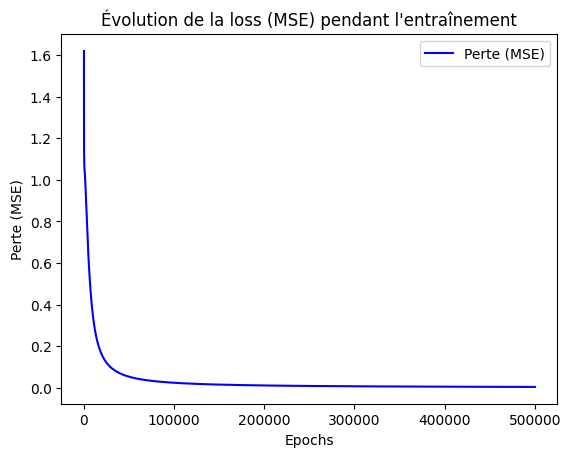

In [9]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([
    [-1.0],
    [1.0],
    [1.0],
    [-1.0]
])

model = create_MLP([2, 3, 1])

losses = train_MLP(model, X, y, 100_000, 0.1, True)

predict_MLP(model, X, 1, True)

plot_losses(losses)